# Profitability Analysis of U.S. Retail Apparel Firms (2019–2024)

This notebook converts the original Python script into a structured, presentation-friendly Jupyter Notebook for the Track 2 GitHub Data Analysis Project.

## Goals
- Load firm-level financial data from SimFin
- Filter U.S. listed firms in the *Retail - Apparel & Specialty* industry
- Clean and preprocess the data
- Construct financial ratios
- Generate descriptive statistics and visualizations
- Run regression models for profitability analysis

In [1]:
import warnings
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import simfin as sf

## 1. Basic Settings

This section defines warning filters, display options, project folders, and core analysis parameters.

In [5]:
warnings.filterwarnings(
    "ignore",
    message=".*date_parser.*deprecated.*",
    category=FutureWarning,
    module=r"simfin\.load"
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

API_KEY = "a9f00d54-604b-42f2-9757-4bdfb780d46b"
DATA_DIR = "simfin_data"
OUTPUT_DIR = Path("outputs_robustness")
OUTPUT_DIR.mkdir(exist_ok=True)

START_YEAR = 2019
END_YEAR = 2024
TARGET_INDUSTRY = "Retail - Apparel & Specialty"
MIN_YEARS_PER_FIRM = 3

# Manually excluded atypical firms
EXCLUDED_TICKERS = ["AMZN", "EBAY", "HD", "RGR"]

## 2. Utility Function

Winsorization is applied to reduce the influence of extreme outliers in financial ratios.

In [6]:
def winsorize_series(s, lower=0.01, upper=0.99):
    q_low = s.quantile(lower)
    q_high = s.quantile(upper)
    return s.clip(lower=q_low, upper=q_high)

## 3. Load SimFin Data

In [7]:
if not API_KEY:
    raise ValueError("SIMFIN_API_KEY is not set. Please export or set it in your environment.")

sf.set_api_key(API_KEY)
sf.set_data_dir(DATA_DIR)

print("Loading SimFin datasets...")
income = sf.load_income(variant="annual", market="us").reset_index()
balance = sf.load_balance(variant="annual", market="us").reset_index()
companies = sf.load_companies(market="us").reset_index()
industries = sf.load_industries().reset_index()
print("Data loaded.\n")

Loading SimFin datasets...
Dataset "us-income-annual" on disk (5 days old).
- Loading from disk ... Done!
Dataset "us-balance-annual" on disk (5 days old).
- Loading from disk ... Done!
Dataset "us-companies" on disk (5 days old).
- Loading from disk ... Done!
Dataset "industries" on disk (5 days old).
- Loading from disk ... Done!
Data loaded.



## 4. Merge Company and Industry Information

In [8]:
company_industry = companies.merge(industries, on="IndustryId", how="left")

target_companies = company_industry.loc[
    company_industry["Industry"].eq(TARGET_INDUSTRY),
    ["Ticker", "SimFinId", "Company Name", "Sector", "Industry"]
].drop_duplicates()

print("Target industry:", TARGET_INDUSTRY)
print("Number of firms before exclusion:", target_companies["Ticker"].nunique())
print("\nExcluded tickers:", EXCLUDED_TICKERS)

target_companies = target_companies[
    ~target_companies["Ticker"].isin(EXCLUDED_TICKERS)
].copy()

print("Number of firms after exclusion:", target_companies["Ticker"].nunique())
print("\nSample firms after exclusion:")
target_companies.head(20)

Target industry: Retail - Apparel & Specialty
Number of firms before exclusion: 180

Excluded tickers: ['AMZN', 'EBAY', 'HD', 'RGR']
Number of firms after exclusion: 176

Sample firms after exclusion:


,Ticker,SimFinId,Company Name,Sector,Industry
18,AAP,184955,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty
143,AEO,173396,AMERICAN EAGLE OUTFITTERS INC,Consumer Cyclical,Retail - Apparel & Specialty
231,AKA,14864216,a.k.a. Brands Holding Corp.,Consumer Cyclical,Retail - Apparel & Specialty
370,ANF,188522,ABERCROMBIE & FITCH CO /DE/,Consumer Cyclical,Retail - Apparel & Specialty
419,APRN,978546,"Blue Apron Holdings, Inc.",Consumer Cyclical,Retail - Apparel & Specialty
459,ARHS,1397113,"Arhaus, Inc.",Consumer Cyclical,Retail - Apparel & Specialty
462,ARKO,11795184,Arko Corp.,Consumer Cyclical,Retail - Apparel & Specialty
473,ARO,93605,AEROPOSTALE INC,Consumer Cyclical,Retail - Apparel & Specialty
508,ASNA,35533,"Ascena Retail Group, Inc.",Consumer Cyclical,Retail - Apparel & Specialty
510,ASO,1271540,"Academy Sports & Outdoors, Inc.",Consumer Cyclical,Retail - Apparel & Specialty


## 5. Merge Financial Data

In [9]:
balance_keep = balance[
    ["Ticker", "SimFinId", "Report Date", "Fiscal Year", "Total Assets"]
].copy()

df = income.merge(
    balance_keep,
    on=["Ticker", "SimFinId", "Report Date", "Fiscal Year"],
    how="left"
)

df = df.merge(
    target_companies,
    on=["Ticker", "SimFinId"],
    how="inner"
)

# Keep target years only
df = df[(df["Fiscal Year"] >= START_YEAR) & (df["Fiscal Year"] <= END_YEAR)].copy()

# Keep annual observations
if "Fiscal Period" in df.columns:
    df = df[df["Fiscal Period"].isin(["FY", "Q4", "Annual"]) | df["Fiscal Period"].isna()].copy()

print("Merged panel shape:", df.shape)
df.head()

Merged panel shape: (522, 32)


,Ticker,Report Date,SimFinId,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Research & Development,Depreciation & Amortization,Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Abnormal Gains (Losses),Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Extraordinary Gains (Losses),Net Income,Net Income (Common),Total Assets,Company Name,Sector,Industry
0,AAP,2020-12-31,184955,USD,2020,FY,2021-02-22,2023-02-28,68748000.0,69003000.0,1.010632e+10,-5.624707e+09,4.481614e+09,-3.731707e+09,-3.731707e+09,NaN,NaN,749907000.0,-50870000.0,-46886000.0,699037000.0,-48022000.0,651015000.0,-157994000.0,493021000,NaN,493021000,493021000,1.183964e+10,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty
1,AAP,2021-12-31,184955,USD,2021,FY,2022-02-15,2024-03-12,62854000.0,63348000.0,1.099799e+10,-6.074039e+09,4.923950e+09,-4.101585e+09,-4.101585e+09,NaN,NaN,822365000.0,-39872000.0,-37791000.0,782493000.0,NaN,782493000.0,-185878000.0,596615000,NaN,596615000,596615000,1.219421e+10,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty
2,AAP,2022-12-31,184955,USD,2022,FY,2023-02-28,2025-02-26,60351000.0,60717000.0,9.148874e+09,-4.916004e+09,4.232870e+09,-3.708252e+09,-3.708252e+09,NaN,NaN,524618000.0,-57017000.0,-50841000.0,467601000.0,-7408000.0,460193000.0,-99657000.0,360536000,103866000.0,464402000,464402000,1.198645e+10,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty
3,AEO,2021-01-31,173396,USD,2020,FY,2021-03-11,2023-03-13,166455000.0,166455000.0,3.759113e+09,-2.610966e+09,1.148147e+09,-1.139666e+09,-9.772640e+08,NaN,-162402000.0,8481000.0,-20928000.0,-24610000.0,-12447000.0,-279826000.0,-292273000.0,82999000.0,-209274000,NaN,-209274000,-209274000,3.434806e+09,AMERICAN EAGLE OUTFITTERS INC,Consumer Cyclical,Retail - Apparel & Specialty
4,AEO,2022-01-31,173396,USD,2021,FY,2022-03-14,2024-03-15,167491000.0,208933000.0,5.010785e+09,-3.018995e+09,1.991790e+09,-1.388781e+09,-1.222000e+09,NaN,-166781000.0,603009000.0,-32143000.0,-34632000.0,570866000.0,-11944000.0,558922000.0,-139293000.0,419629000,NaN,419629000,419629000,3.786643e+09,AMERICAN EAGLE OUTFITTERS INC,Consumer Cyclical,Retail - Apparel & Specialty


## 6. Keep Required Columns and Clean Data

In [10]:
required_cols = [
    "Ticker",
    "Company Name",
    "Sector",
    "Industry",
    "Fiscal Year",
    "Report Date",
    "Revenue",
    "Cost of Revenue",
    "Selling, General & Administrative",
    "Operating Income (Loss)",
    "Net Income",
    "Total Assets"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()

df = df.rename(columns={
    "Selling, General & Administrative": "SGA",
    "Operating Income (Loss)": "Operating_Income",
    "Net Income": "Net_Income",
    "Cost of Revenue": "COGS",
    "Fiscal Year": "Fiscal_Year"
})

df = df.replace([np.inf, -np.inf], np.nan)
df = df[df["Revenue"].notna() & (df["Revenue"] > 0)].copy()
df = df.dropna(subset=["COGS", "SGA", "Operating_Income", "Net_Income", "Total Assets"]).copy()
df = df[df["Total Assets"] > 0].copy()

print("Data shape after initial cleaning:", df.shape)
df.head()

Data shape after initial cleaning: (486, 12)


,Ticker,Company Name,Sector,Industry,Fiscal_Year,Report Date,Revenue,COGS,SGA,Operating_Income,Net_Income,Total Assets
0,AAP,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty,2020,2020-12-31,1.010632e+10,-5.624707e+09,-3.731707e+09,749907000.0,493021000,1.183964e+10
1,AAP,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty,2021,2021-12-31,1.099799e+10,-6.074039e+09,-4.101585e+09,822365000.0,596615000,1.219421e+10
2,AAP,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty,2022,2022-12-31,9.148874e+09,-4.916004e+09,-3.708252e+09,524618000.0,464402000,1.198645e+10
3,AEO,AMERICAN EAGLE OUTFITTERS INC,Consumer Cyclical,Retail - Apparel & Specialty,2020,2021-01-31,3.759113e+09,-2.610966e+09,-9.772640e+08,8481000.0,-209274000,3.434806e+09
4,AEO,AMERICAN EAGLE OUTFITTERS INC,Consumer Cyclical,Retail - Apparel & Specialty,2021,2022-01-31,5.010785e+09,-3.018995e+09,-1.222000e+09,603009000.0,419629000,3.786643e+09


## 7. Construct Financial Variables

In [11]:
df["COGS_ratio"] = -df["COGS"] / df["Revenue"]
df["SGA_ratio"] = -df["SGA"] / df["Revenue"]
df["Operating_margin"] = df["Operating_Income"] / df["Revenue"]
df["Net_margin"] = df["Net_Income"] / df["Revenue"]
df["ROA"] = df["Net_Income"] / df["Total Assets"]
df["Log_Assets"] = np.log(df["Total Assets"])

# Remove unreasonable values
df = df[df["COGS_ratio"].between(0, 2)].copy()
df = df[df["SGA_ratio"].between(0, 2)].copy()
df = df[df["Operating_margin"].between(-2, 2)].copy()
df = df[df["Net_margin"].between(-2, 2)].copy()
df = df[df["ROA"].between(-2, 2)].copy()

# Keep firms with at least MIN_YEARS_PER_FIRM observations
firm_year_counts = df.groupby("Ticker")["Fiscal_Year"].nunique().reset_index(name="Years")
eligible_tickers = firm_year_counts.loc[
    firm_year_counts["Years"] >= MIN_YEARS_PER_FIRM, "Ticker"
]
df = df[df["Ticker"].isin(eligible_tickers)].copy()

# Winsorize key ratios
for col in ["COGS_ratio", "SGA_ratio", "Operating_margin", "Net_margin", "ROA"]:
    df[col] = winsorize_series(df[col], 0.01, 0.99)

print("Cleaned robustness dataset shape:", df.shape)
df.head()

Cleaned robustness dataset shape: (450, 18)


,Ticker,Company Name,Sector,Industry,Fiscal_Year,Report Date,Revenue,COGS,SGA,Operating_Income,Net_Income,Total Assets,COGS_ratio,SGA_ratio,Operating_margin,Net_margin,ROA,Log_Assets
0,AAP,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty,2020,2020-12-31,1.010632e+10,-5.624707e+09,-3.731707e+09,749907000.0,493021000,1.183964e+10,0.556553,0.369245,0.074202,0.048783,0.041642,23.194719
1,AAP,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty,2021,2021-12-31,1.099799e+10,-6.074039e+09,-4.101585e+09,822365000.0,596615000,1.219421e+10,0.552286,0.372940,0.074774,0.054248,0.048926,23.224227
2,AAP,ADVANCE AUTO PARTS INC,Consumer Cyclical,Retail - Apparel & Specialty,2022,2022-12-31,9.148874e+09,-4.916004e+09,-3.708252e+09,524618000.0,464402000,1.198645e+10,0.537334,0.405323,0.057342,0.050761,0.038744,23.207042
3,AEO,AMERICAN EAGLE OUTFITTERS INC,Consumer Cyclical,Retail - Apparel & Specialty,2020,2021-01-31,3.759113e+09,-2.610966e+09,-9.772640e+08,8481000.0,-209274000,3.434806e+09,0.694570,0.259972,0.002256,-0.055671,-0.060927,21.957226
4,AEO,AMERICAN EAGLE OUTFITTERS INC,Consumer Cyclical,Retail - Apparel & Specialty,2021,2022-01-31,5.010785e+09,-3.018995e+09,-1.222000e+09,603009000.0,419629000,3.786643e+09,0.602499,0.243874,0.120342,0.083745,0.110818,22.054746


## 8. Save Cleaned Data

In [12]:
cleaned_path = OUTPUT_DIR / "retail_apparel_specialty_robustness_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print(f"Saved cleaned dataset to: {cleaned_path}")

Saved cleaned dataset to: outputs_robustness\retail_apparel_specialty_robustness_cleaned.csv


## 9. Descriptive Statistics

In [13]:
desc = df[
    ["Revenue", "COGS", "SGA", "Operating_Income", "Net_Income",
     "COGS_ratio", "SGA_ratio", "Operating_margin", "Net_margin", "ROA"]
].describe()

desc_path = OUTPUT_DIR / "descriptive_statistics.csv"
desc.to_csv(desc_path)
print(f"Saved descriptive statistics to: {desc_path}")
desc

Saved descriptive statistics to: outputs_robustness\descriptive_statistics.csv


,Revenue,COGS,SGA,Operating_Income,Net_Income,COGS_ratio,SGA_ratio,Operating_margin,Net_margin,ROA
count,4.500000e+02,4.500000e+02,4.500000e+02,4.500000e+02,4.500000e+02,450.000000,450.000000,450.000000,450.000000,450.000000
mean,6.340759e+09,-4.102325e+09,-1.617243e+09,5.147956e+08,3.166627e+08,0.568705,0.349960,0.041198,0.006891,0.025958
std,1.236627e+10,8.556609e+09,2.586271e+09,1.399758e+09,1.026910e+09,0.150285,0.156276,0.159655,0.170824,0.181314
min,1.214679e+07,-6.480200e+10,-2.033200e+10,-1.504000e+09,-3.944000e+09,0.129322,0.025464,-0.611507,-0.860850,-0.588427
25%,6.407575e+08,-4.200346e+09,-1.941068e+09,-2.732407e+06,-2.061745e+07,0.469548,0.247090,-0.004643,-0.019339,-0.029917
50%,1.662861e+09,-9.795315e+08,-5.198779e+08,9.143650e+07,5.057900e+07,0.581531,0.320417,0.061165,0.039292,0.045160
75%,7.273025e+09,-3.144968e+08,-2.804168e+08,4.330022e+08,2.821250e+08,0.665756,0.426206,0.118112,0.086197,0.117670
max,9.705900e+10,-2.103900e+06,-3.458099e+06,1.209300e+10,8.442000e+09,0.864551,0.875951,0.584073,0.467364,0.816750


## 10. Company Summary

In [14]:
company_summary = (
    df.groupby(["Ticker", "Company Name"], as_index=False)
    .agg(
        Avg_Revenue=("Revenue", "mean"),
        Avg_COGS_ratio=("COGS_ratio", "mean"),
        Avg_SGA_ratio=("SGA_ratio", "mean"),
        Avg_Operating_Margin=("Operating_margin", "mean"),
        Avg_Net_Margin=("Net_margin", "mean"),
        Avg_ROA=("ROA", "mean"),
        Years=("Fiscal_Year", "nunique")
    )
    .sort_values("Avg_Net_Margin", ascending=False)
)

company_summary_path = OUTPUT_DIR / "company_summary.csv"
company_summary.to_csv(company_summary_path, index=False)
print(f"Saved company summary to: {company_summary_path}")
company_summary.head(15)

Saved company summary to: outputs_robustness\company_summary.csv


,Ticker,Company Name,Avg_Revenue,Avg_COGS_ratio,Avg_SGA_ratio,Avg_Operating_Margin,Avg_Net_Margin,Avg_ROA,Years
93,WINA,WINMARK CORP,7.804428e+07,0.129322,0.315930,0.584073,0.464180,0.816750,5
68,OLPX,"Olaplex Holdings, Inc.",4.931718e+08,0.289475,0.251422,0.366766,0.207053,0.072232,5
15,BKE,BUCKLE INC,1.203973e+09,0.514160,0.265308,0.220532,0.173085,0.249079,5
30,DECK,DECKERS OUTDOOR CORP,3.719328e+09,0.462312,0.335670,0.202018,0.161430,0.217058,5
69,ORLY,O REILLY AUTOMOTIVE INC,1.437253e+10,0.482407,0.311895,0.205698,0.151089,0.167454,5
63,LULU,lululemon athletica inc.,7.795284e+09,0.426840,0.353929,0.218344,0.145521,0.189549,5
8,AZO,AUTOZONE INC,1.589225e+10,0.472924,0.327513,0.199563,0.144772,0.148377,5
95,WSM,WILLIAMS SONOMA INC,7.833147e+09,0.571230,0.262928,0.165842,0.127086,0.204752,5
11,BBWI,"Bath & Body Works, Inc.",7.322400e+09,0.544196,0.249319,0.206485,0.126703,0.152855,5
73,RH,RH,3.152024e+09,0.525246,0.283272,0.191482,0.124674,0.103948,3


## 11. Year Summary

In [15]:
year_summary = (
    df.groupby("Fiscal_Year", as_index=False)
    .agg(
        Mean_COGS_ratio=("COGS_ratio", "mean"),
        Mean_SGA_ratio=("SGA_ratio", "mean"),
        Mean_Operating_Margin=("Operating_margin", "mean"),
        Mean_Net_Margin=("Net_margin", "mean"),
        Mean_ROA=("ROA", "mean")
    )
    .sort_values("Fiscal_Year")
)

year_summary_path = OUTPUT_DIR / "year_summary.csv"
year_summary.to_csv(year_summary_path, index=False)
print(f"Saved year summary to: {year_summary_path}")
year_summary

Saved year summary to: outputs_robustness\year_summary.csv


,Fiscal_Year,Mean_COGS_ratio,Mean_SGA_ratio,Mean_Operating_Margin,Mean_Net_Margin,Mean_ROA
0,2020,0.586371,0.348726,0.024706,-0.020443,-0.008810
1,2021,0.559118,0.337618,0.065069,0.044532,0.075511
2,2022,0.574691,0.343982,0.038386,-0.000151,0.010167
3,2023,0.565529,0.357033,0.039824,0.002696,0.020539
4,2024,0.554926,0.367034,0.036292,0.006429,0.032133


## 12. Visualizations

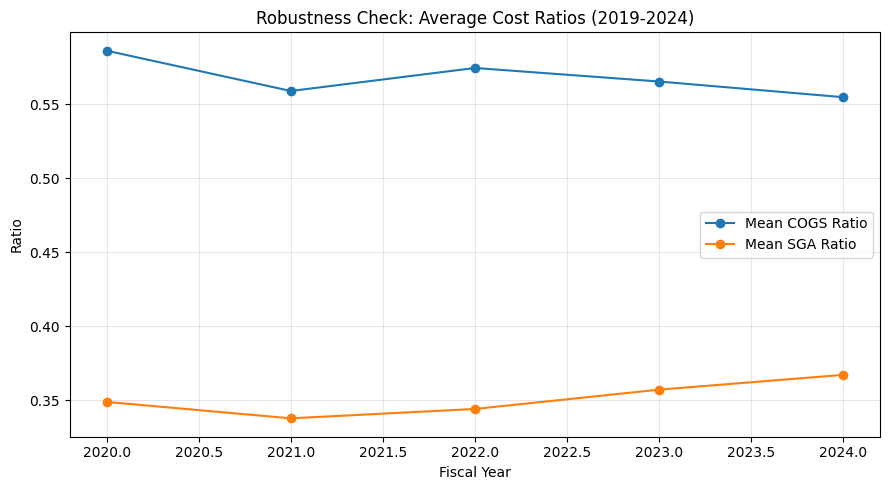

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(year_summary["Fiscal_Year"], year_summary["Mean_COGS_ratio"], marker="o", label="Mean COGS Ratio")
plt.plot(year_summary["Fiscal_Year"], year_summary["Mean_SGA_ratio"], marker="o", label="Mean SGA Ratio")
plt.title("Robustness Check: Average Cost Ratios (2019-2024)")
plt.xlabel("Fiscal Year")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cost_ratios_over_time.png", dpi=300)
plt.show()

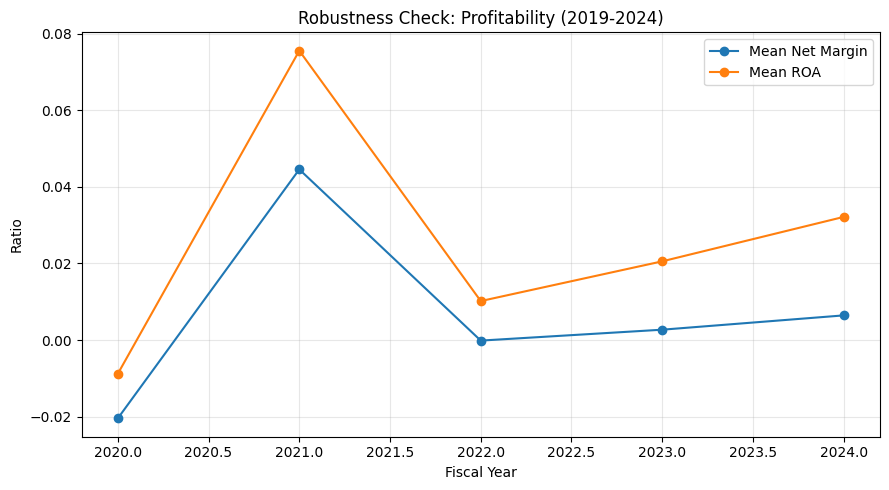

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(year_summary["Fiscal_Year"], year_summary["Mean_Net_Margin"], marker="o", label="Mean Net Margin")
plt.plot(year_summary["Fiscal_Year"], year_summary["Mean_ROA"], marker="o", label="Mean ROA")
plt.title("Robustness Check: Profitability (2019-2024)")
plt.xlabel("Fiscal Year")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "profitability_over_time.png", dpi=300)
plt.show()

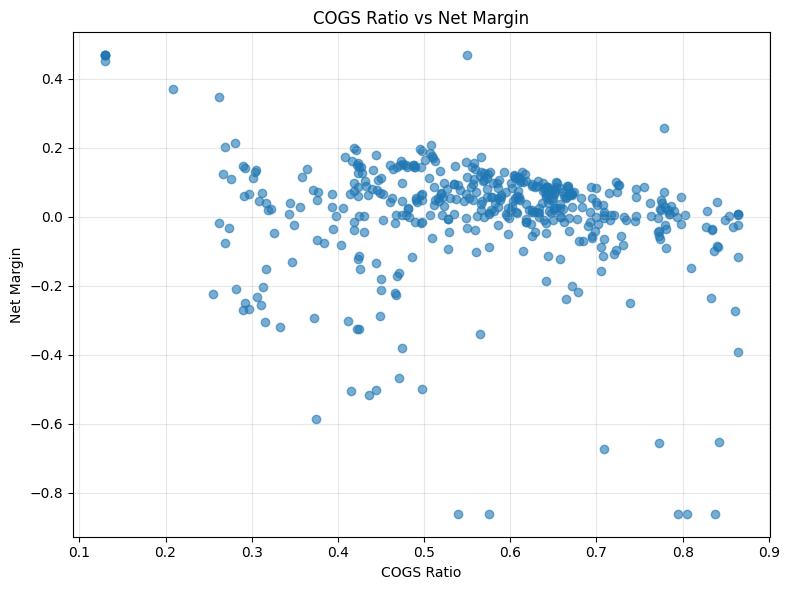

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(df["COGS_ratio"], df["Net_margin"], alpha=0.6)
plt.title("COGS Ratio vs Net Margin")
plt.xlabel("COGS Ratio")
plt.ylabel("Net Margin")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cogs_vs_net_margin.png", dpi=300)
plt.show()

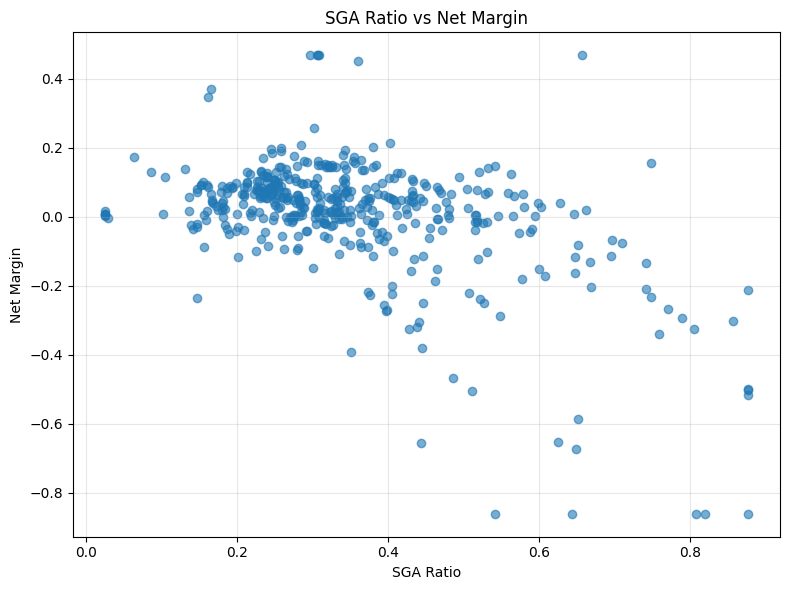

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(df["SGA_ratio"], df["Net_margin"], alpha=0.6)
plt.title("SGA Ratio vs Net Margin")
plt.xlabel("SGA Ratio")
plt.ylabel("Net Margin")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sga_vs_net_margin.png", dpi=300)
plt.show()

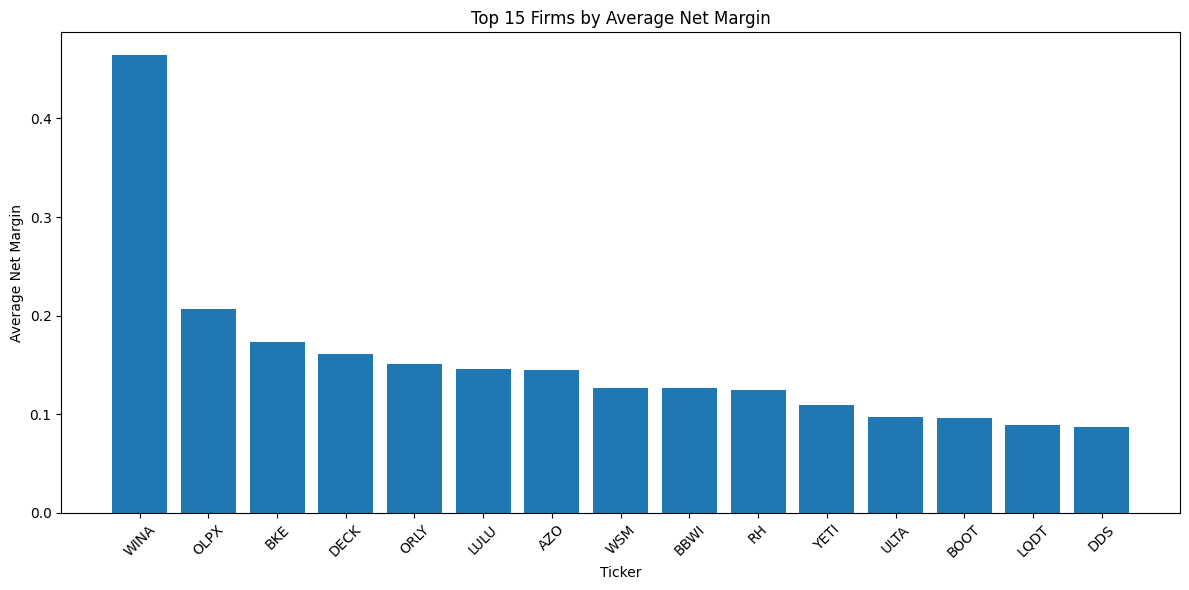

In [20]:
top15 = company_summary.head(15).copy()
plt.figure(figsize=(12, 6))
plt.bar(top15["Ticker"], top15["Avg_Net_Margin"])
plt.title("Top 15 Firms by Average Net Margin")
plt.xlabel("Ticker")
plt.ylabel("Average Net Margin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top15_net_margin.png", dpi=300)
plt.show()

## 13. Regression 1: Net Margin

In [21]:
reg_df1 = df.dropna(subset=["Net_margin", "COGS_ratio", "SGA_ratio", "Log_Assets"]).copy()

model_net = smf.ols(
    formula="Net_margin ~ COGS_ratio + SGA_ratio + Log_Assets + C(Fiscal_Year)",
    data=reg_df1
).fit(cov_type="HC3")

net_regression_txt = OUTPUT_DIR / "regression_net_margin.txt"
with open(net_regression_txt, "w", encoding="utf-8") as f:
    f.write(model_net.summary().as_text())

print("Net margin regression finished.")
print(f"Saved net margin regression summary to: {net_regression_txt}")
model_net.summary()

Net margin regression finished.
Saved net margin regression summary to: outputs_robustness\regression_net_margin.txt


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Net_margin   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     30.25
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           3.72e-34
Time:                        19:52:44   Log-Likelihood:                 335.12
No. Observations:                 450   AIC:                            -654.2
Df Residuals:                     442   BIC:                            -621.4
Df Model:                           7                                         
Covariance Type:                  HC3                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.5738      0.123      4.668      0.000       0.333       0.815
C(Fiscal_Year)[T.2021]     0.0351      0.019      1.864      0.062      -0.002       0.072
C(Fiscal_Year)[T.2022]     0.0071      0.018      0.387      0.699      -0.029       0.043
C(Fiscal_Year)[T.2023]     0.0148      0.016      0.903      0.367      -0.017       0.047
C(Fiscal_Year)[T.2024]     0.0195      0.016      1.200      0.230      -0.012       0.051
COGS_ratio                -0.7093      0.070    -10.103      0.000      -0.847      -0.572
SGA_ratio                 -0.8936      0.083    -10.828      0.000      -1.055      -0.732
Log_Assets                 0.0063      0.004      1.558      0.119      -0.002       0.014
==============================================================================
Omnibus:                      172.722   Durbin-Watson:                   0.922
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1762.543
Skew:                          -1.350   Prob(JB):                         0.00
Kurtosis:                      12.312   Cond. No.                         358.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## 14. Regression 2: ROA

In [22]:
reg_df2 = df.dropna(subset=["ROA", "COGS_ratio", "SGA_ratio", "Log_Assets"]).copy()

model_roa = smf.ols(
    formula="ROA ~ COGS_ratio + SGA_ratio + Log_Assets + C(Fiscal_Year)",
    data=reg_df2
).fit(cov_type="HC3")

roa_regression_txt = OUTPUT_DIR / "regression_roa.txt"
with open(roa_regression_txt, "w", encoding="utf-8") as f:
    f.write(model_roa.summary().as_text())

print("ROA regression finished.")
print(f"Saved ROA regression summary to: {roa_regression_txt}")
model_roa.summary()

ROA regression finished.
Saved ROA regression summary to: outputs_robustness\regression_roa.txt


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    ROA   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     30.42
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           2.46e-34
Time:                        19:52:44   Log-Likelihood:                 265.31
No. Observations:                 450   AIC:                            -514.6
Df Residuals:                     442   BIC:                            -481.7
Df Model:                           7                                         
Covariance Type:                  HC3                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.6581      0.191      3.441      0.001       0.283       1.033
C(Fiscal_Year)[T.2021]     0.0548      0.021      2.646      0.008       0.014       0.095
C(Fiscal_Year)[T.2022]     0.0061      0.021      0.293      0.770      -0.035       0.047
C(Fiscal_Year)[T.2023]     0.0206      0.018      1.126      0.260      -0.015       0.056
C(Fiscal_Year)[T.2024]     0.0326      0.019      1.717      0.086      -0.005       0.070
COGS_ratio                -0.7338      0.098     -7.496      0.000      -0.926      -0.542
SGA_ratio                 -0.8377      0.083    -10.117      0.000      -1.000      -0.675
Log_Assets                 0.0026      0.007      0.395      0.693      -0.010       0.016
==============================================================================
Omnibus:                       66.786   Durbin-Watson:                   0.886
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              570.862
Skew:                          -0.267   Prob(JB):                    1.09e-124
Kurtosis:                       8.492   Cond. No.                         358.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## 15. Save Coefficient Tables

In [23]:
coef_net = pd.DataFrame({
    "Variable": model_net.params.index,
    "Coefficient": model_net.params.values,
    "P_value": model_net.pvalues.values
})
coef_net_path = OUTPUT_DIR / "regression_coefficients_net_margin.csv"
coef_net.to_csv(coef_net_path, index=False)

coef_roa = pd.DataFrame({
    "Variable": model_roa.params.index,
    "Coefficient": model_roa.params.values,
    "P_value": model_roa.pvalues.values
})
coef_roa_path = OUTPUT_DIR / "regression_coefficients_roa.csv"
coef_roa.to_csv(coef_roa_path, index=False)

print(f"Saved net margin coefficients to: {coef_net_path}")
print(f"Saved ROA coefficients to: {coef_roa_path}")

Saved net margin coefficients to: outputs_robustness\regression_coefficients_net_margin.csv
Saved ROA coefficients to: outputs_robustness\regression_coefficients_roa.csv


## 16. Conclusion

This notebook provides a complete Python-based financial data analysis workflow for U.S. retail apparel firms. It combines data cleaning, ratio construction, descriptive analysis, visualization, and regression modeling in a format suitable for GitHub publication and academic submission.

### Possible next steps
- Add interpretation of coefficient signs and statistical significance
- Compare results across industries
- Extend the model to panel fixed-effects estimation